In [7]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import functions

importlib.reload(functions)

<module 'functions' from 'c:\\Users\\katin\\Lokale_dokumenter\\Fagprojekt---Group-Equivariance\\fag_projekt\\notebooks\\functions.py'>

In [ ]:
import torch 
import torch.nn as nn
import torch.nn.functional  as F

from torch import Tensor
from torchvision import transforms

import pandas as pd
import PIL.Image as Image

import kagglehub

In [ ]:
path = kagglehub.dataset_download("zalando-research/fashionmnist")

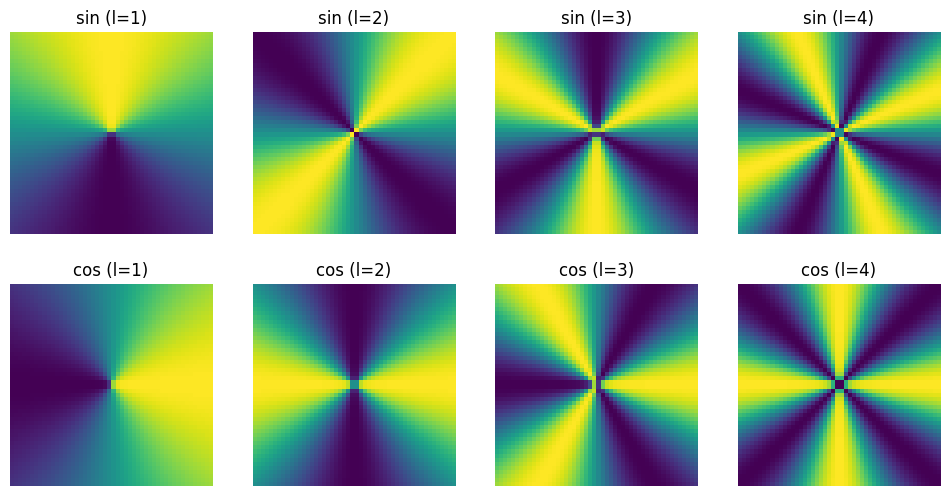

In [ ]:
n = 50
basis, radius_map = functions.fourier_basis(n,4,plot = True)

In [ ]:
def MLP(r):
    return np.sin(r)

w = torch.tensor(np.vectorize(MLP)(radius_map))
new_kernel = w * basis[1]
plt.imshow(basis[1].squeeze_())
plt.show()
plt.imshow(new_kernel.squeeze_())


F.conv2d laver convolution. skal bare give den kernel
den kernel den får er et en radialafhængig vægt ganget på hver pixel i den givne fourierbasis.
(hmm det betyde vel at vi ikke kan genbruge convolutionen til flere kernels, fordi den har ganget vægte på)

In [ ]:
class LiftingLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super(LiftingLayer, self).__init__()
        
        # Define learnable parameters
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        
        if bias:
            self.bias = nn.Parameter(torch.randn(out_features))
        else:
            self.bias = None

    def forward(self, x):
        # x shape: (batch_size, in_features)
        #fourier folder 
        w = self.weight * fourier ???
        out = x @ w.t()  # matrix multiplication
        
        if self.bias is not None:
            out += self.bias
        
        return out

# MNIST


In [261]:
#Laver vores MNIST image
RESIZE_SIZE = 280

df = pd.read_csv(path + '/fashion-mnist_train.csv')
row1 = df.iloc[0, 1:].values
pixel = row1.reshape(28,28).astype(np.uint8)

img = Image.fromarray(pixel)
print(img.resize((280, 280), Image.NEAREST))

transform = transforms.ToTensor()

img = img.resize((RESIZE_SIZE, RESIZE_SIZE), Image.NEAREST)

image = transform(img)


<PIL.Image.Image image mode=L size=280x280 at 0x1678D3080>


In [257]:
image.unsqueeze_(1)
image.shape

torch.Size([1, 1, 280, 280])

## Convolutions

In [ ]:
temp = basis[-1].clone()
temp = temp.float()
temp.unsqueeze_(0)
temp.shape


torch.Size([1, 1, 50, 50])

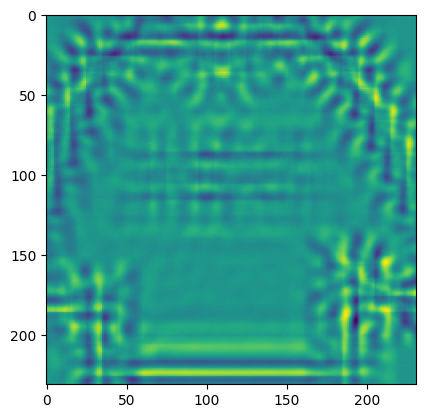

In [259]:
output = F.conv2d(input=image, weight=temp)

output.squeeze_()
output.shape
plt.imshow(output)